# Bayesian Hierarchical Pitcher ERA Forecasting Project

**This script demonstrates:**
  - Bayesian hierarchical (multilevel) modeling with PyMC
  - Partial pooling across pitchers to handle small samples
  - Posterior predictive distributions for uncertainty quantification
  - Forecasting with credible intervals (not just point estimates)

**Real-world analogy:**
  A pitcher with 3 starts has noisy ERA data. A flat model either
  overfits that noise or ignores it. A hierarchical model "borrows
  strength" from the population of all pitchers to regularize estimates
  — exactly how teams handle call-ups and prospect projections.

**Dependencies:**
  pip install pymc numpy pandas matplotlib arviz

── Simulated Pitcher Data (first 10 rows) ──
 pitcher_id  innings  observed_era  true_era
          0    188.0          3.63      4.34
          1     93.0          4.40      3.27
          2     40.0          1.69      4.70
          3    168.0          4.56      4.85
          4    129.0          2.70      2.54
          5    143.0          3.61      3.06
          6     28.0          5.72      4.20
          7     69.0          4.93      3.85
          8    155.0          3.77      4.09
          9    168.0          3.01      3.42

League mean observed ERA : 3.77
League std  observed ERA : 1.32

── Running MCMC (fast demo version) ──


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_league, sigma_league, eta, sigma_obs_scale, new_pitcher_era, new_pitcher_obs]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 6 seconds.
There were 65 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [new_pitcher_obs]



── Model Summary (key parameters) ──
                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu_league        3.813  0.191   3.359    4.077      0.056    0.041      13.0      20.0   1.15
sigma_league     1.326  0.163   1.094    1.731      0.041    0.030      18.0      29.0   1.13
sigma_obs_scale  1.103  0.677   0.427    2.454      0.281    0.210       5.0      25.0   1.41

── Shrinkage: Observed vs Posterior ERA (sorted by innings) ──
 pitcher_id  innings  observed_era  posterior_era_mean  shrinkage
         23     11.0          1.72                1.87      -0.15
         36     17.0          0.00                0.23      -0.23
          6     28.0          5.72                5.65       0.07
         39     31.0          2.59                2.63      -0.04
         37     36.0          0.70                0.78      -0.08
         19     36.0          4.36                4.32       0.04
          2     40.0          1.69                1.74      

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/bayesian_era_model.png'

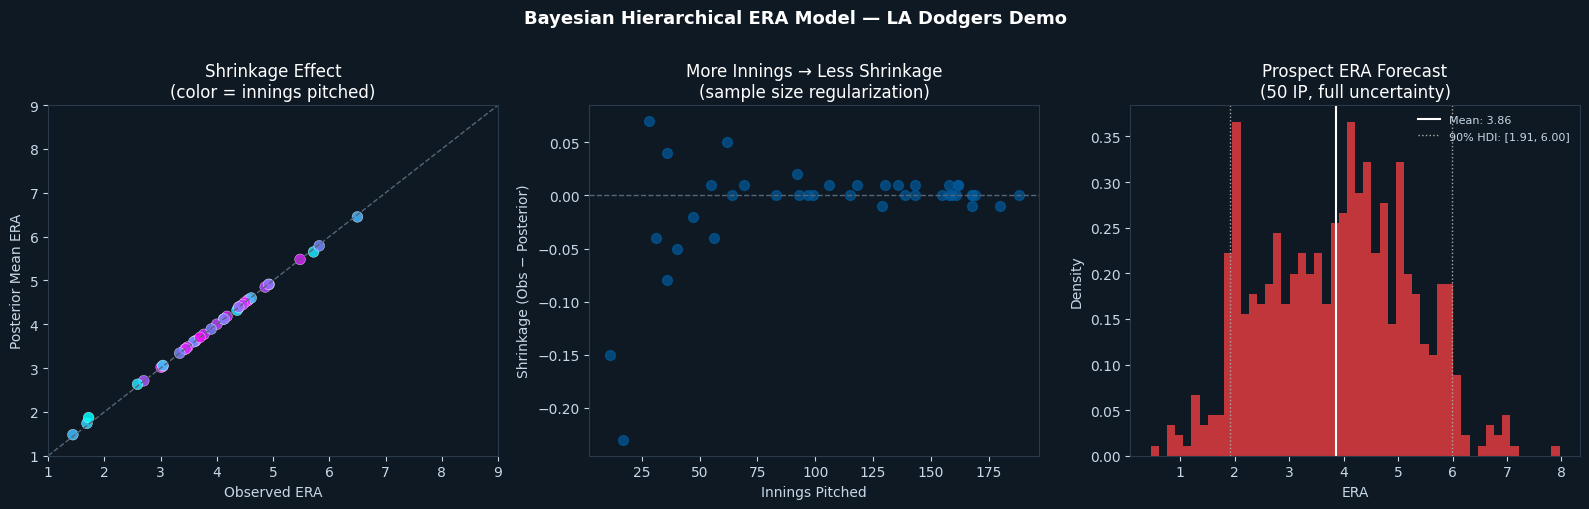

In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
# 1. SIMULATE STATCAST-STYLE PITCHER DATA
# ─────────────────────────────────────────────
# In production you'd load from a real database (Baseball Savant, etc.)
# Here we simulate a realistic distribution of pitcher-season ERAs.

rng = np.random.default_rng(42)

N_PITCHERS = 40
TRUE_LEAGUE_ERA = 4.10          # approximate MLB average ERA
TRUE_LEAGUE_SD  = 0.80          # spread across pitchers

# Each pitcher has a true underlying "talent" ERA
true_pitcher_eras = rng.normal(TRUE_LEAGUE_ERA, TRUE_LEAGUE_SD, N_PITCHERS)
true_pitcher_eras = np.clip(true_pitcher_eras, 1.5, 8.0)

# Number of innings pitched varies — some pitchers have very small samples
innings_pitched = rng.integers(10, 200, N_PITCHERS).astype(float)

# Observed ERA = true ERA + noise (inversely proportional to sample size)
# More innings → more reliable observed ERA
obs_noise = TRUE_LEAGUE_SD * np.sqrt(200 / innings_pitched)
observed_era = true_pitcher_eras + rng.normal(0, obs_noise, N_PITCHERS)
observed_era = np.clip(observed_era, 0.0, 12.0)

pitcher_ids = np.arange(N_PITCHERS)

df = pd.DataFrame({
    "pitcher_id":    pitcher_ids,
    "innings":       innings_pitched,
    "observed_era":  np.round(observed_era, 2),
    "true_era":      np.round(true_pitcher_eras, 2),   # hidden in real life
})

print("── Simulated Pitcher Data (first 10 rows) ──")
print(df.head(10).to_string(index=False))
print(f"\nLeague mean observed ERA : {observed_era.mean():.2f}")
print(f"League std  observed ERA : {observed_era.std():.2f}\n")


# ─────────────────────────────────────────────
# 2. BAYESIAN HIERARCHICAL MODEL
# ─────────────────────────────────────────────
# Model structure:
#
#   μ_league  ~ Normal(4.0, 1.0)          # league-average ERA prior
#   σ_league  ~ HalfNormal(1.0)           # spread across pitchers
#   η_i       ~ Normal(0, 1)              # non-centered parameterization
#   ERA_i     = μ_league + σ_league * η_i # per-pitcher latent ERA
#   σ_obs_i   = σ_obs_scale / sqrt(IP_i)  # heteroskedastic obs noise
#   obs_ERA_i ~ Normal(ERA_i, σ_obs_i)    # likelihood
#
# Non-centered parameterization (η) improves sampler geometry.
# Heteroskedastic σ_obs accounts for innings-pitched sample size.

with pm.Model() as hierarchical_era_model:

    # ── Hyperpriors (league-level) ──
    mu_league  = pm.Normal("mu_league",  mu=4.0, sigma=1.0)
    sigma_league = pm.HalfNormal("sigma_league", sigma=1.0)

    # ── Per-pitcher latent ERA (non-centered) ──
    eta = pm.Normal("eta", mu=0, sigma=1, shape=N_PITCHERS)
    pitcher_era = pm.Deterministic("pitcher_era", mu_league + sigma_league * eta)

    # ── Observation noise (scales with 1/sqrt(IP)) ──
    sigma_obs_scale = pm.HalfNormal("sigma_obs_scale", sigma=1.0)
    sigma_obs = sigma_obs_scale / np.sqrt(innings_pitched)

    # ── Likelihood ──
    obs = pm.Normal(
        "obs",
        mu=pitcher_era,
        sigma=sigma_obs,
        observed=observed_era,
    )

    # ── Posterior predictive for a NEW pitcher (e.g., a prospect) ──
    # 50 innings pitched — high uncertainty expected
    sigma_new = sigma_obs_scale / np.sqrt(50.0)
    new_pitcher_era = pm.Normal("new_pitcher_era", mu=mu_league, sigma=sigma_league)
    new_pitcher_obs = pm.Normal("new_pitcher_obs", mu=new_pitcher_era, sigma=sigma_new)


# ─────────────────────────────────────────────
# 3. SAMPLING
# ─────────────────────────────────────────────
print("── Running MCMC (fast demo version) ──")
with hierarchical_era_model:
    idata = pm.sample(
        draws=300,
        tune=300,
        chains=2,
        cores=1,                 # important on some Mac setups
        target_accept=0.9,
        progressbar=True,
        random_seed=42,
    )

    pm.sample_posterior_predictive(
        idata,
        var_names=["new_pitcher_obs"],
        extend_inferencedata=True,
        random_seed=42,
    )

print("\n── Model Summary (key parameters) ──")
summary = az.summary(idata, var_names=["mu_league", "sigma_league", "sigma_obs_scale"])
print(summary.to_string())


# ─────────────────────────────────────────────
# 4. SHRINKAGE ANALYSIS
# ─────────────────────────────────────────────
# Key insight: Bayesian partial pooling "shrinks" extreme observed ERAs
# toward the league mean — more so for pitchers with fewer innings.

posterior_era_means = idata.posterior["pitcher_era"].mean(dim=("chain", "draw")).values
posterior_era_hdi   = az.hdi(idata, var_names=["pitcher_era"], hdi_prob=0.90)

shrinkage = observed_era - posterior_era_means   # positive = shrunk down

df["posterior_era_mean"] = np.round(posterior_era_means, 2)
df["shrinkage"]          = np.round(shrinkage, 2)

print("\n── Shrinkage: Observed vs Posterior ERA (sorted by innings) ──")
print(df.sort_values("innings")[["pitcher_id","innings","observed_era","posterior_era_mean","shrinkage"]].head(15).to_string(index=False))


# ─────────────────────────────────────────────
# 5. VISUALIZATION
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f1923")
for ax in axes:
    ax.set_facecolor("#0f1923")
    ax.tick_params(colors="#c8d8e8")
    ax.xaxis.label.set_color("#c8d8e8")
    ax.yaxis.label.set_color("#c8d8e8")
    ax.title.set_color("#ffffff")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a3a4a")

DODGER_BLUE = "#005A9C"
DODGER_GOLD = "#EF3E42"

# Plot 1: Observed vs Posterior ERA (shrinkage effect)
ax = axes[0]
ax.scatter(df["observed_era"], df["posterior_era_mean"],
           c=df["innings"], cmap="cool", s=60, alpha=0.85, edgecolors="white", linewidths=0.3)
lim = [1, 9]
ax.plot(lim, lim, "--", color="#556677", linewidth=1, label="No shrinkage")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Observed ERA"); ax.set_ylabel("Posterior Mean ERA")
ax.set_title("Shrinkage Effect\n(color = innings pitched)")

# Plot 2: Shrinkage magnitude vs innings pitched
ax = axes[1]
ax.scatter(df["innings"], df["shrinkage"], color=DODGER_BLUE, alpha=0.7, s=50)
ax.axhline(0, color="#556677", linestyle="--", linewidth=1)
ax.set_xlabel("Innings Pitched"); ax.set_ylabel("Shrinkage (Obs − Posterior)")
ax.set_title("More Innings → Less Shrinkage\n(sample size regularization)")

# Plot 3: Posterior predictive for a new prospect (50 IP)
ax = axes[2]
new_era_samples = idata.posterior_predictive["new_pitcher_obs"].values.flatten()
ax.hist(new_era_samples, bins=50, color=DODGER_GOLD, alpha=0.8, edgecolor="none", density=True)
ax.axvline(new_era_samples.mean(), color="white", linestyle="-", linewidth=1.5,
           label=f"Mean: {new_era_samples.mean():.2f}")
hdi_90 = az.hdi(new_era_samples, hdi_prob=0.90)
ax.axvline(hdi_90[0], color="#aaaaaa", linestyle=":", linewidth=1)
ax.axvline(hdi_90[1], color="#aaaaaa", linestyle=":", linewidth=1,
           label=f"90% HDI: [{hdi_90[0]:.2f}, {hdi_90[1]:.2f}]")
ax.legend(fontsize=8, labelcolor="#c8d8e8", framealpha=0)
ax.set_xlabel("ERA"); ax.set_ylabel("Density")
ax.set_title("Prospect ERA Forecast\n(50 IP, full uncertainty)")

plt.suptitle("Bayesian Hierarchical ERA Model — LA Dodgers Demo",
             fontsize=13, color="white", y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/bayesian_era_model.png", dpi=150,
            bbox_inches="tight", facecolor="#0f1923")
print("\n── Plot saved: bayesian_era_model.png ──")
plt.show()

In [5]:
# ── Probabilistic Forecasting for a New Pitcher ──
import numpy as np
import pandas as pd

# Pull posterior predictive draws for the new pitcher ERA
new_pitcher_forecast = (
    idata.posterior_predictive["new_pitcher_obs"]
    .values
    .reshape(-1)
)

# Pull posterior draws for league mean ERA
league_mean_draws = (
    idata.posterior["mu_league"]
    .values
    .reshape(-1)
)

# Summary metrics
forecast_mean = np.mean(new_pitcher_forecast)
forecast_median = np.median(new_pitcher_forecast)
forecast_std = np.std(new_pitcher_forecast)

p10, p25, p50, p75, p90 = np.percentile(
    new_pitcher_forecast, [10, 25, 50, 75, 90]
)
lower_80, upper_80 = np.percentile(new_pitcher_forecast, [10, 90])
lower_95, upper_95 = np.percentile(new_pitcher_forecast, [2.5, 97.5])

# Example probability questions
prob_below_3_50 = np.mean(new_pitcher_forecast < 3.50)
prob_below_4_00 = np.mean(new_pitcher_forecast < 4.00)
prob_between_3_50_4_50 = np.mean(
    (new_pitcher_forecast >= 3.50) & (new_pitcher_forecast <= 4.50)
)
prob_above_5_00 = np.mean(new_pitcher_forecast > 5.00)

# Compare to league average
# If lengths differ, align by trimming to the shorter length
n = min(len(new_pitcher_forecast), len(league_mean_draws))
prob_better_than_league = np.mean(
    new_pitcher_forecast[:n] < league_mean_draws[:n]
)

forecast_summary = pd.DataFrame({
    "metric": [
        "Forecast mean ERA",
        "Forecast median ERA",
        "Forecast std dev",
        "80% predictive interval",
        "95% predictive interval",
        "P(ERA < 3.50)",
        "P(ERA < 4.00)",
        "P(3.50 <= ERA <= 4.50)",
        "P(ERA > 5.00)",
        "P(ERA better than league avg)"
    ],
    "value": [
        round(forecast_mean, 3),
        round(forecast_median, 3),
        round(forecast_std, 3),
        f"({lower_80:.3f}, {upper_80:.3f})",
        f"({lower_95:.3f}, {upper_95:.3f})",
        f"{prob_below_3_50:.1%}",
        f"{prob_below_4_00:.1%}",
        f"{prob_between_3_50_4_50:.1%}",
        f"{prob_above_5_00:.1%}",
        f"{prob_better_than_league:.1%}",
    ]
})

print("── Probabilistic Forecast for New Pitcher ──")
print(forecast_summary.to_string(index=False))

── Probabilistic Forecast for New Pitcher ──
                       metric          value
            Forecast mean ERA          3.861
          Forecast median ERA          3.961
             Forecast std dev           1.34
      80% predictive interval (2.029, 5.636)
      95% predictive interval (1.501, 6.096)
                P(ERA < 3.50)          39.5%
                P(ERA < 4.00)          51.0%
       P(3.50 <= ERA <= 4.50)          27.5%
                P(ERA > 5.00)          22.2%
P(ERA better than league avg)          45.2%


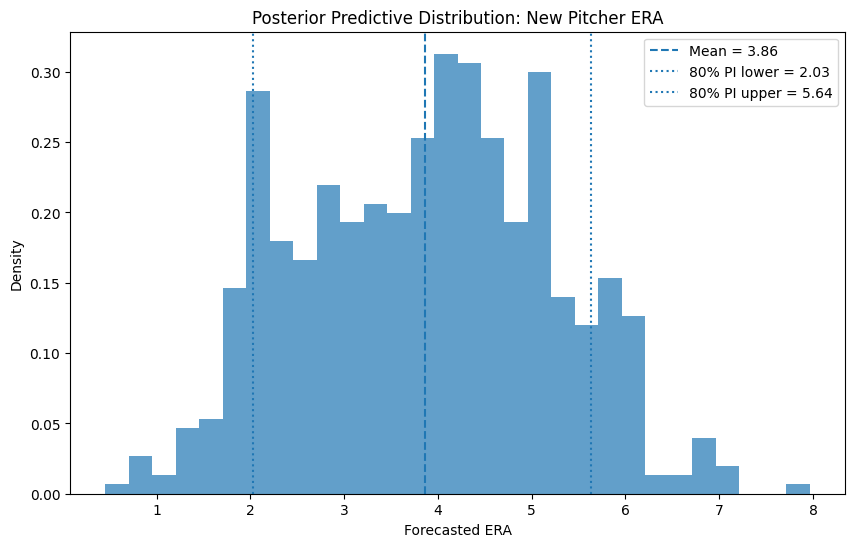

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(new_pitcher_forecast, bins=30, density=True, alpha=0.7)
plt.axvline(forecast_mean, linestyle="--", label=f"Mean = {forecast_mean:.2f}")
plt.axvline(lower_80, linestyle=":", label=f"80% PI lower = {lower_80:.2f}")
plt.axvline(upper_80, linestyle=":", label=f"80% PI upper = {upper_80:.2f}")
plt.xlabel("Forecasted ERA")
plt.ylabel("Density")
plt.title("Posterior Predictive Distribution: New Pitcher ERA")
plt.legend()
plt.show()